In [1]:
import sys
import os

sys.path.append(os.path.abspath('../'))

from qualibrate import QualibrationNode
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.polynomial import Polynomial

2026-03-28 10:41:00,226 - qm - INFO     - Starting session: 15d5ae46-6629-4e25-9402-5f04a8cda1ef


In [2]:
node  = QualibrationNode(name="quantum_memory_gate_error")

2026-03-28 10:41:01,378 - qualibrate - INFO - Creating node quantum_memory_gate_error


In [3]:
from pathlib import Path
data_path = Path("../data/QPT_vs_ellipsoid").resolve()

In [4]:
# gate_error_idx = np.arange(753,953,1)
gate_error_idx = np.arange(1926,2017,3)

gate_error_list = []
qpt_exp_fidelity_list = []
qpt_robustness_list = []
for idx in gate_error_idx:
    res = node.load_from_id(idx,base_path = data_path).results
    gate_error_list.append(res['initial_parameters']['alpha']-1)
    qpt_exp_fidelity_list.append(res['results']['q0']['quantum information']['mitigated']['fidelity']) 
    qpt_robustness_list.append(res['results']['q0']['quantum information']['mitigated']['Quantum Memory Robustness'])

In [5]:
from quam_libs.QPT_theory import compute_qpt_theory

alphas = np.linspace(0, 0.3, len(gate_error_idx))  
qpt_choi_matrices_list, qpt_theory_fidelities_list = compute_qpt_theory(alphas, q_meas=0,verbose=True)

Starting QPT theory computation (31 points)...
Measurement quality q = 0.0000
[  1/31] Alpha = +0.0000 | Process Fidelity = 0.999992
[  2/31] Alpha = +0.0100 | Process Fidelity = 0.997065
[  3/31] Alpha = +0.0200 | Process Fidelity = 0.993962
[  4/31] Alpha = +0.0300 | Process Fidelity = 0.990692
[  5/31] Alpha = +0.0400 | Process Fidelity = 0.987261
[  6/31] Alpha = +0.0500 | Process Fidelity = 0.983662
[  7/31] Alpha = +0.0600 | Process Fidelity = 0.979902
[  8/31] Alpha = +0.0700 | Process Fidelity = 0.975982
[  9/31] Alpha = +0.0800 | Process Fidelity = 0.971904
[ 10/31] Alpha = +0.0900 | Process Fidelity = 0.967676
[ 11/31] Alpha = +0.1000 | Process Fidelity = 0.963280
[ 12/31] Alpha = +0.1100 | Process Fidelity = 0.958737
[ 13/31] Alpha = +0.1200 | Process Fidelity = 0.954042
[ 14/31] Alpha = +0.1300 | Process Fidelity = 0.949197
[ 15/31] Alpha = +0.1400 | Process Fidelity = 0.944202
[ 16/31] Alpha = +0.1500 | Process Fidelity = 0.939064
[ 17/31] Alpha = +0.1600 | Process Fidelit

In [6]:
from scipy.stats import pearsonr

r,p_value = pearsonr(qpt_exp_fidelity_list, qpt_theory_fidelities_list)
r_squared = r**2


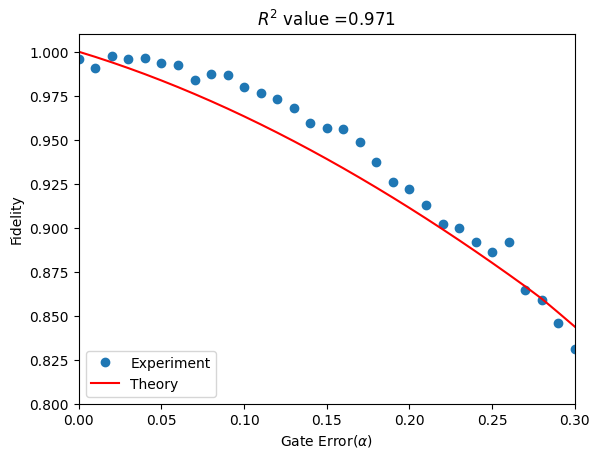

In [7]:
fig, ax = plt.subplots()
ax.plot(gate_error_list, qpt_exp_fidelity_list, 'o', label=f'Experiment')
ax.plot(alphas, qpt_theory_fidelities_list, linestyle='-', color='r', label='Theory')


ax.set_xlabel('Gate Error($\\alpha$)')
ax.set_ylabel('Fidelity')
ax.set_title(f'$R^2$ value ={r_squared:.3}')
ax.set_xlim(0,0.3)
ax.set_ylim(0.8,1.01)
ax.legend(loc='lower left')
plt.show()


# Load QPT ellipsoid gate error data

In [9]:
# Read the CSV file
csv_path = Path("../data/QPT_vs_ellipsoid/QPT10000_ellipsoid180_robustness_data.csv").resolve()
df_QPT = pd.read_csv(csv_path)

# Read the CSV file
csv_path = Path("../_not_in_used/QPT_vs_Ellipsoid_data_new.csv").resolve()
df_ellipsoid = pd.read_csv(csv_path)

# Read the CSV file
csv_path = Path("../_not_in_used/qpt_gst_ellipsoid.csv").resolve()
df_gst = pd.read_csv(csv_path)

In [10]:
filter_std_parameter = 5
# Extract columns from dataframe
x_data_all = df_QPT['gate_fidelity'].values
ellipsoid_y_all = df_ellipsoid['ellipsoid robustness'].values
ellipsoid_err_all = df_ellipsoid['ellipsoid error bar'].values
QPT_y_all = df_QPT['QPT_robustness'].values
QPT_err_all = df_QPT['QPT_robustness_std'].values
gst_y_all = df_ellipsoid['GST robustness'].values
gst_err_all = df_ellipsoid['GST error bar'].values
# Filter by ellipsoid std: keep points with std below median + filter_std_parameter*std
# AND filter by gate fidelity: keep points with gate fidelity >= 0.84
# AND filter by robustness: keep points with robustness >= 0.73
err_threshold = np.median(ellipsoid_err_all) + filter_std_parameter*np.std(ellipsoid_err_all)
filter_mask = (ellipsoid_err_all <= err_threshold) & (x_data_all >= 0.7) 
# filter_mask = None
x_data = x_data_all[filter_mask]
ellipsoid_y = ellipsoid_y_all[filter_mask]
ellipsoid_err = ellipsoid_err_all[filter_mask]
QPT_y = QPT_y_all[filter_mask]
QPT_err = QPT_err_all[filter_mask]
gst_y_all = gst_y_all[filter_mask]

In [11]:
# Fit linear regression for both datasets
p_QPT = Polynomial.fit(x_data, QPT_y, 1)
p_ellipsoid = Polynomial.fit(x_data, ellipsoid_y, 1)

# Generate fitting lines
x_fit = np.linspace(x_data.min(), x_data.max()+0.1, 100)
QPT_y_fit = p_QPT(x_fit)
ellipsoid_y_fit = p_ellipsoid(x_fit)

print(f"Fitted Results:")
print(f"\nQPT: y = {p_QPT.coef[1]:.6f} * x + {p_QPT.coef[0]:.6f}")
print(f"Ellipsoid: y = {p_ellipsoid.coef[1]:.6f} * x + {p_ellipsoid.coef[0]:.6f}")

Fitted Results:

QPT: y = 0.195661 * x + 0.745612
Ellipsoid: y = 0.003538 * x + 0.966964


## QPT theory

In [12]:
from quam_libs.analyzer import QuantumMemoryAnalyze
qpt_theory_robustness_list = []

qpt_choi_matrices_list, qpt_noise_fidelities_list = compute_qpt_theory(alphas, q_meas=0.018,verbose=True)

for J in qpt_choi_matrices_list:
    theory_robustness = QuantumMemoryAnalyze.memory_robustness(0.5*J) # 0.5 is for normalization purpose.
    qpt_theory_robustness_list.append(theory_robustness)
qpt_theory_robustness_list = np.array(qpt_theory_robustness_list)

Starting QPT theory computation (31 points)...
Measurement quality q = 0.0180
[  1/31] Alpha = +0.0000 | Process Fidelity = 0.981991
[  2/31] Alpha = +0.0100 | Process Fidelity = 0.980238
[  3/31] Alpha = +0.0200 | Process Fidelity = 0.978172
[  4/31] Alpha = +0.0300 | Process Fidelity = 0.975841
[  5/31] Alpha = +0.0400 | Process Fidelity = 0.973268
[  6/31] Alpha = +0.0500 | Process Fidelity = 0.970452
[  7/31] Alpha = +0.0600 | Process Fidelity = 0.967391
[  8/31] Alpha = +0.0700 | Process Fidelity = 0.964083
[  9/31] Alpha = +0.0800 | Process Fidelity = 0.960556
[ 10/31] Alpha = +0.0900 | Process Fidelity = 0.956792
[ 11/31] Alpha = +0.1000 | Process Fidelity = 0.952792
[ 12/31] Alpha = +0.1100 | Process Fidelity = 0.948562
[ 13/31] Alpha = +0.1200 | Process Fidelity = 0.944116
[ 14/31] Alpha = +0.1300 | Process Fidelity = 0.939451
[ 15/31] Alpha = +0.1400 | Process Fidelity = 0.934565
[ 16/31] Alpha = +0.1500 | Process Fidelity = 0.929466
[ 17/31] Alpha = +0.1600 | Process Fidelit

## ellipsoid theory

In [13]:
from quam_libs.ellipsoid_theory import simulate_markovian_robustness
ellipsoid_theortic_value = simulate_markovian_robustness(
        t1=16e-6,
        t2=10e-6,
        t_delay=1e-9,
        error=0.023,
        n_points=200,
        return_details=False,
    )
print(f"theory robustness = {ellipsoid_theortic_value:.6g}")

/Users/jackchao/Desktop/Project/publication/quantum_memory/data_availability/quantum_memory_data/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


theory robustness = 0.965381


## plot

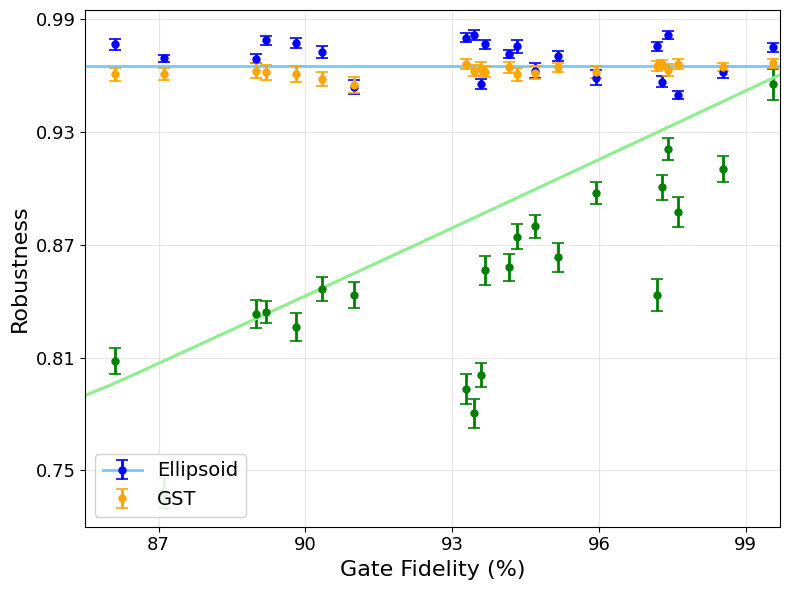


Fitted Results (x in percentage scale [85, 100])

QPT:
  y = 0.001957 * x + 0.745612
  OR: y = 0.195661 * x + 0.745612  (x in [0, 1])

Ellipsoid:
  y = 0.000035 * x + 0.966964
  OR: y = 0.003538 * x + 0.966964  (x in [0, 1])


In [ ]:
# Convert to percentage scale for plotting (multiply by 100)
x_plot = x_data * 100
# x_fit_plot = x_fit * 100

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# 1. Plot QPT data
err_qpt = ax.errorbar(x_plot, QPT_y, yerr=QPT_err,
                      linestyle='none', fmt='o', markersize=5, markerfacecolor='green', 
                      markeredgecolor='green', ecolor='green', elinewidth=2, capsize=4, capthick=1.2)
line_qpt = ax.plot(np.array(qpt_theory_fidelities_list)*100, qpt_theory_robustness_list, 
                   color='#90EE90', linewidth=2) 

# 2. Plot Ellipsoid data 
err_ell = ax.errorbar(x_plot, ellipsoid_y, yerr=ellipsoid_err,
                      linestyle='none', fmt='o', markersize=5, markerfacecolor='blue', 
                      markeredgecolor='blue', ecolor='blue', elinewidth=2, capsize=4, capthick=1.2)

line_ell = ax.plot([85, 100], [ellipsoid_theortic_value, ellipsoid_theortic_value], 
                   color="#79c7ffff", linewidth=2) 

# 3. Plot GST data
line_gst = ax.plot(x_plot, gst_y_all, 'd', markersize=5, markerfacecolor='orange', 
                   markeredgecolor='orange')

err_gst = ax.errorbar(x_plot, gst_y_all, yerr=gst_err_all,
                      linestyle='none', fmt='o', markersize=5, markerfacecolor='orange', 
                      markeredgecolor='orange', ecolor='orange', elinewidth=2, capsize=4, capthick=1.2)
line_qpt = ax.plot(np.array(qpt_theory_fidelities_list)*100, qpt_theory_robustness_list, 
                   color='#90EE90', linewidth=2) 

# Customize plot
ax.set_xlim(85.5, 99.7)
ax.set_ylim(0.72, 0.995)
ax.set_xlabel('Gate Fidelity (%)', fontsize=16)
ax.set_ylabel('Robustness', fontsize=16)
ax.tick_params(axis='x', labelsize=13) 
ax.tick_params(axis='y', labelsize=13) 
ax.set_xticks([87, 90 ,93 ,96, 99])
# ax.set_yticks([0.95, 0.96, 0.97, 0.98, 0.99])
ax.set_yticks([0.75, 0.81, 0.87, 0.93, 0.99])
ax.grid(True, alpha=0.3)


# ax.legend(
#     [(line_ell[0], err_ell), err_gst,(line_qpt[0], err_qpt)], 
#     ['Ellipsoid', 'GST','QPT'], 
#     fontsize=14, 
#     loc='lower right',
#     framealpha=0.9 
# )

ax.legend(
    [(line_ell[0], err_ell), err_gst], 
    ['Ellipsoid', 'GST'], 
    fontsize=14, 
    loc='lower left',
    framealpha=0.9 
)


plt.tight_layout()
# plt.savefig('paper_figure/FIg2_qpt_ellipsoid_gst.pdf', dpi=600, bbox_inches='tight')
# plt.savefig('paper_figure/Appendix_B.pdf', dpi=600, bbox_inches='tight')

plt.show()

# Print fit results
print(f"\n{'='*60}")
print(f"Fitted Results (x in percentage scale [85, 100])")
print(f"{'='*60}")
a_QPT = p_QPT.coef[1] / 100
b_QPT = p_QPT.coef[0]
print(f"\nQPT:")
print(f"  y = {a_QPT:.6f} * x + {b_QPT:.6f}")
print(f"  OR: y = {p_QPT.coef[1]:.6f} * x + {b_QPT:.6f}  (x in [0, 1])")

a_ellipsoid = p_ellipsoid.coef[1] / 100
b_ellipsoid = p_ellipsoid.coef[0]
print(f"\nEllipsoid:")
print(f"  y = {a_ellipsoid:.6f} * x + {b_ellipsoid:.6f}")
print(f"  OR: y = {p_ellipsoid.coef[1]:.6f} * x + {b_ellipsoid:.6f}  (x in [0, 1])")
print(f"{'='*60}")


In [15]:
df = pd.DataFrame({
    'gate_error': gate_error_list,
    'gate_fidelity':df_QPT['gate_fidelity'].values,
    'qpt_theory_fidelities': qpt_theory_fidelities_list,
    'qpt_exp_robustness': df_QPT['QPT_robustness'].values,
    'qpt_exp_robustness_std': df_QPT['QPT_robustness_std'].values,
    'qpt_sim_robustness': qpt_theory_robustness_list,
    'ellipsoid_exp_robustness': df_ellipsoid['ellipsoid robustness'].values,
    'ellipsoid_exp_robustness_std': df_ellipsoid['ellipsoid error bar'].values,
    'ellipsoid_sim_robustness': ellipsoid_theortic_value,
    'gst_exp_robustness': df_ellipsoid['GST robustness'].values,
    'gst_exp_robustness_std': df_ellipsoid['GST error bar'].values
    })

In [ ]:
# df.to_csv('data/QPT_ellipsoid_GST.csv', index=False)